In [4]:
import torch
import matplotlib.pyplot as plt
import numpy as np
# import pandas as pd
# import seaborn as sns
# from torch.distributions import constraints
from tqdm.notebook import tqdm

import pyro
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoNormal
from pyro.optim import Adam, Adagrad
import pyro.distributions as dist
import pyro.optim as optim

In [11]:
mu_prior, sigma_prior = torch.tensor(0.0), torch.tensor(10.0)
sigma_like = torch.tensor(1.0)
max_iters = 100_000

# compute true posteriors
true_mu_post = mu_prior
true_sigma_post = sigma_prior

def run_restart(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)

    def single_model(y):
        mu = pyro.sample("mu", dist.Normal(mu_prior, sigma_prior))
        for i in range(len(y)):
            # observe datapoint i using the likelihood
            pyro.sample("obs_{}".format(i), dist.Normal(mu, sigma_like), obs=y[i])
    def multi_model(y):
        mu = pyro.sample("mu", dist.Normal(mu_prior, sigma_prior))
        for i in range(len(y)):
            # observe datapoint i using the likelihood
            pyro.sample("obs_{}".format(i), dist.Normal(mu, sigma_like), obs=y[i])
    y_data = []

    single_guide = AutoNormal(single_model)
    multi_guide = AutoNormal(multi_model)
    # saves params in pyro as "AutoNormal.locs.mu" and "AutoNormal.scales.mu"
    optimizer = pyro.optim.Adam({}) # can leave args empty
    # {"lr": 0.02} is suggested by the vignettes at https://pyro.ai/examples/intro_long.html#Models-in-Pyro
    # lr = 0.005 and betas=(0.95, 0.999) are suggested at the vignette https://pyro.ai/examples/svi_part_i.html
    # default value of adam is lr=0.001, betas=(0.9, 0.999), eps=1e-08, weight_decay=0
    # ^^ taken frm torch.optim.Adam docs since pyro.optim.Adam is a thin wrapper around torch.optim.Adam

    single_elbo = Trace_ELBO()
    multi_elbo = Trace_ELBO(num_particles=100)
    single_svi = SVI(single_model, single_guide, optimizer, single_elbo)
    multi_svi = SVI(multi_model, multi_guide, optimizer, multi_elbo)

    def run_svi(y_data, svi_model, samps=1):
        tracker = {
            'mu_loc': np.zeros(max_iters),
            'mu_scale': np.zeros(max_iters)
        }
        # the 0th entry will be incorrect since 
        # the guide doesn't store the params in pyro 
        # until after the first step is called
        for i in tqdm(range(max_iters), position=0, leave=False, desc="{} MC samples".format(samps)):
            svi_model.step(y_data)
            tracker['mu_loc'][i] = pyro.param("AutoNormal.locs.mu").item()
            tracker['mu_scale'][i] = pyro.param("AutoNormal.scales.mu").item()
        return tracker
    single_tracker = run_svi(y_data, single_svi, samps=1)
    multi_tracker = run_svi(y_data, multi_svi, samps=100)
    return single_tracker, multi_tracker

In [16]:
results = []
for seed in tqdm(range(20), position=1, desc="Random restarts..."):
    result = run_restart(seed)
    results.append(result)

Random restarts...:   0%|          | 0/20 [00:00<?, ?it/s]

1 MC samples:   0%|          | 0/100000 [00:00<?, ?it/s]

100 MC samples:   0%|          | 0/100000 [00:00<?, ?it/s]

1 MC samples:   0%|          | 0/100000 [00:00<?, ?it/s]

100 MC samples:   0%|          | 0/100000 [00:00<?, ?it/s]

...

100 MC samples:   0%|          | 0/100000 [00:00<?, ?it/s]

1 MC samples:   0%|          | 0/100000 [00:00<?, ?it/s]

100 MC samples:   0%|          | 0/100000 [00:00<?, ?it/s]

1 MC samples:   0%|          | 0/100000 [00:00<?, ?it/s]

100 MC samples:   0%|          | 0/100000 [00:00<?, ?it/s]

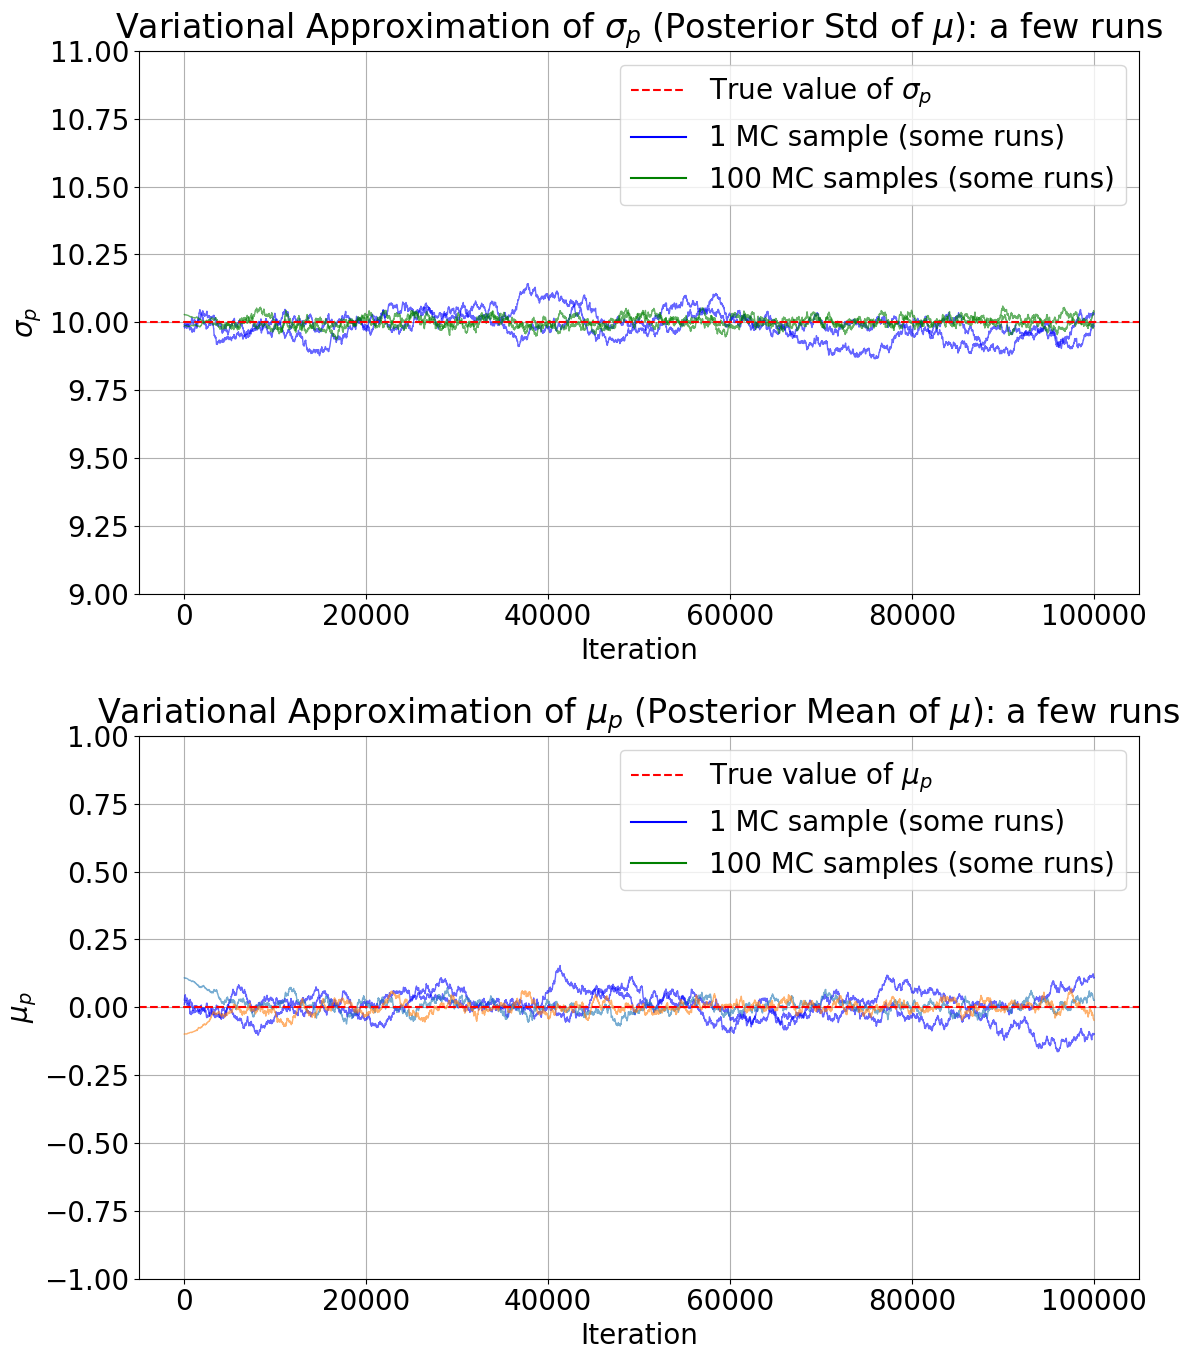

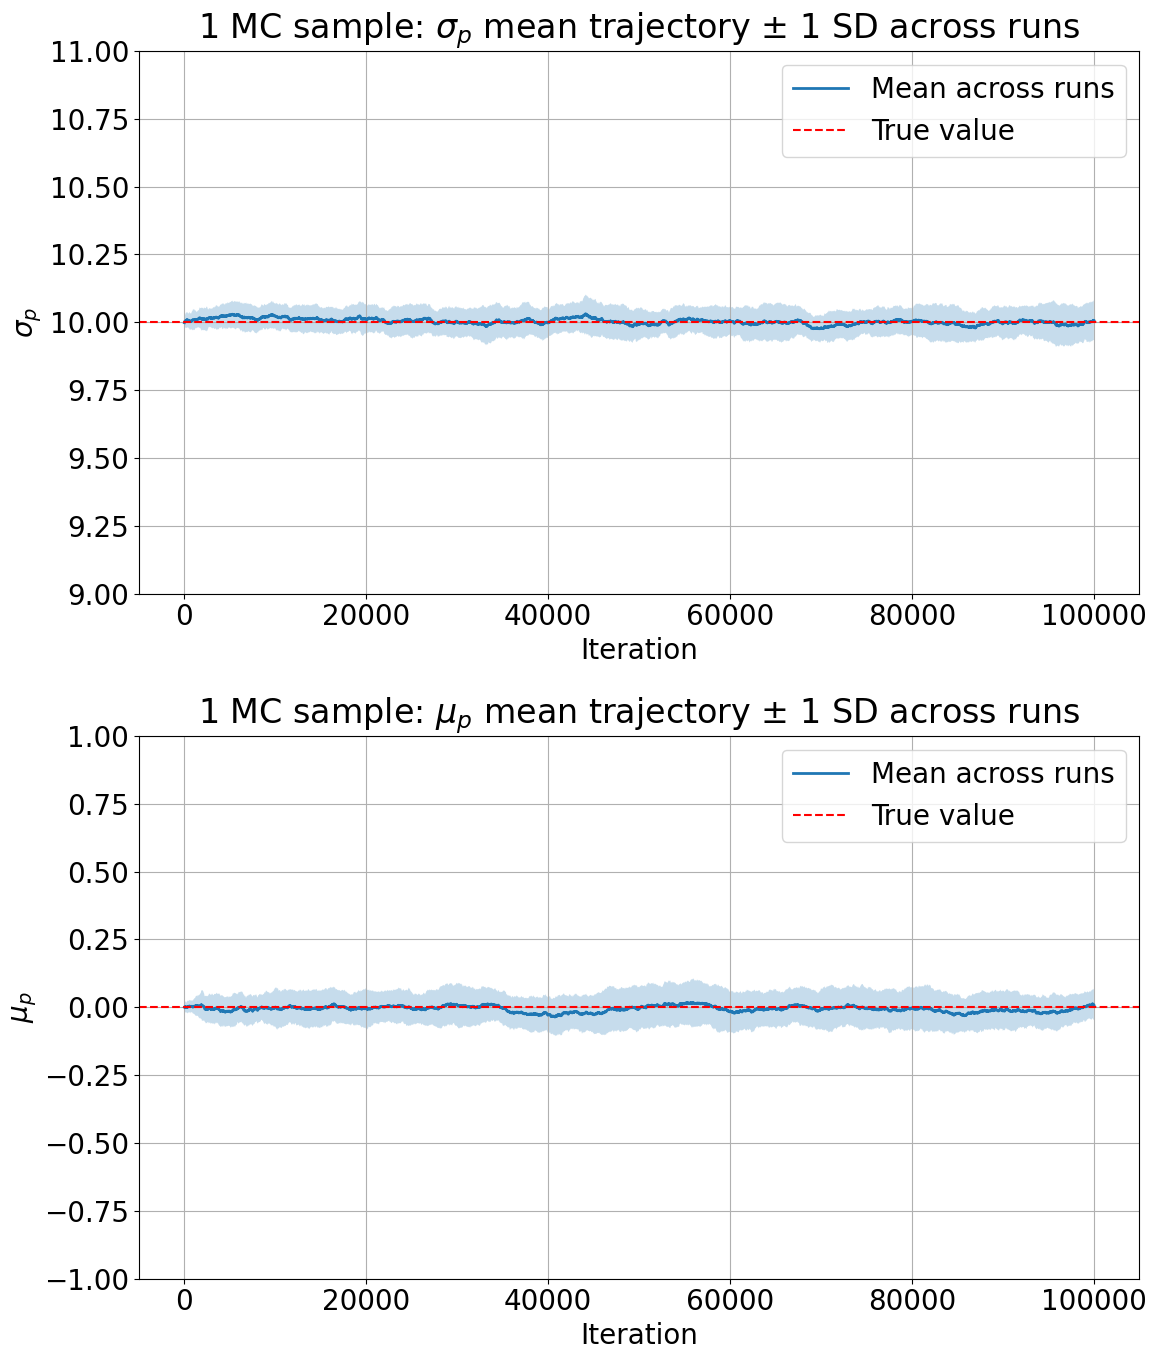

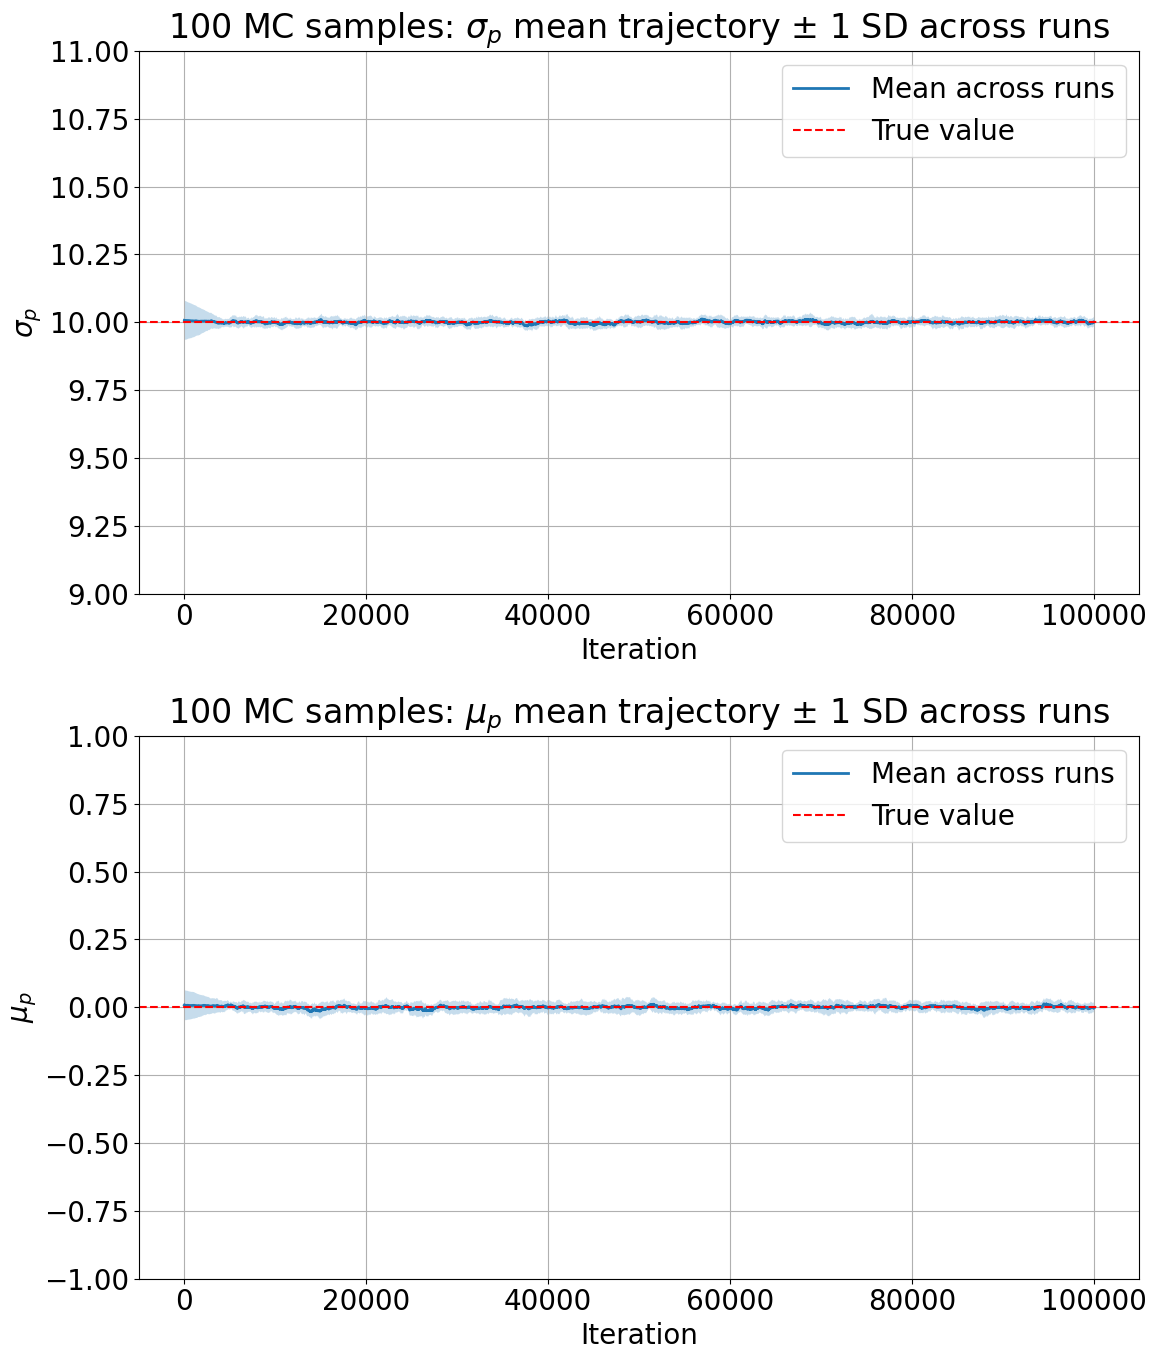

In [17]:
plt.rcParams.update({'font.size': 20})


# ----------------------------
# unpack results -> stacks
# ----------------------------
single_means, single_stds = [], []
multi_means,  multi_stds  = [], []

for single_tracker, multi_tracker in results:
    single_means.append(single_tracker['mu_loc'])
    single_stds.append(single_tracker['mu_scale'])
    multi_means.append(multi_tracker['mu_loc'])
    multi_stds.append(multi_tracker['mu_scale'])

single_means = np.stack(single_means, axis=0)  # (N, T)
single_stds  = np.stack(single_stds,  axis=0)  # (N, T)
multi_means  = np.stack(multi_means,  axis=0)  # (N, T)
multi_stds   = np.stack(multi_stds,   axis=0)  # (N, T)

N, T = single_means.shape
x = np.arange(T)

# ----------------------------
# Plot 1: overlay a few trajectories from each condition
# ----------------------------
k = 2  # how many trajectories to show from each
idx = np.linspace(0, N - 1, k, dtype=int)  # deterministic selection

fig, axs = plt.subplots(2, 1, figsize=(12, 14))

# std of mu
for i in idx:
    axs[0].plot(x, single_stds[i], alpha=0.6, linewidth=1, color='blue')
for i in idx:
    axs[0].plot(x, multi_stds[i],  alpha=0.6, linewidth=1, color='green')

axs[0].axhline(sigma_prior, color='red', linestyle='--', label=r'True value of $\sigma_p$')
axs[0].set_title(r'Variational Approximation of $\sigma_p$ (Posterior Std of $\mu$): a few runs')
axs[0].set_xlabel('Iteration')
axs[0].set_ylabel(r'$\sigma_p$')
axs[0].grid()
axs[0].set_ylim(sigma_prior - 1, sigma_prior + 1)

# mean of mu
for i in idx:
    axs[1].plot(x, single_means[i], alpha=0.6, linewidth=1, color='blue', label=None)
for i in idx:
    axs[1].plot(x, multi_means[i],  alpha=0.6, linewidth=1, label=None)

axs[1].axhline(mu_prior, color='red', linestyle='--', label=r'True value of $\mu_p$')
axs[1].set_title(r'Variational Approximation of $\mu_p$ (Posterior Mean of $\mu$): a few runs')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel(r'$\mu_p$')
axs[1].grid()
axs[1].set_ylim(mu_prior - 1, mu_prior + 1)

# manual legend (so we don’t get 16 duplicate entries)
axs[0].plot([], [], color='blue', label='1 MC sample (some runs)')
axs[0].plot([], [], color='green', label='100 MC samples (some runs)')
axs[0].legend()

axs[1].plot([], [], color='blue', label='1 MC sample (some runs)')
axs[1].plot([], [], color='green', label='100 MC samples (some runs)')
axs[1].legend()

plt.tight_layout()
plt.show()

# ----------------------------
# Plot 2: mean trajectory ± 1 std band across runs (separate plots for 1-MC and 100-MC)
# ----------------------------
def plot_mean_band(ax, x, Y, true_value, title, ylabel):
    """
    Y: (N, T) trajectories
    """
    m = Y.mean(axis=0)
    s = Y.std(axis=0)
    ax.plot(x, m, linewidth=2, label='Mean across runs')
    ax.fill_between(x, m - s, m + s, alpha=0.25)
    ax.axhline(true_value, color='red', linestyle='--', label='True value')
    ax.set_title(title)
    ax.set_xlabel('Iteration')
    ax.set_ylabel(ylabel)
    ax.grid()
    ax.legend()

# 1 MC sample: mean ± sd across runs
fig, axs = plt.subplots(2, 1, figsize=(12, 14))
plot_mean_band(
    axs[0], x, single_stds, sigma_prior,
    r'1 MC sample: $\sigma_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\sigma_p$'
)
axs[0].set_ylim(sigma_prior - 1, sigma_prior + 1)

plot_mean_band(
    axs[1], x, single_means, mu_prior,
    r'1 MC sample: $\mu_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\mu_p$'
)
axs[1].set_ylim(mu_prior - 1, mu_prior + 1)

plt.tight_layout()
plt.show()

# 100 MC samples: mean ± sd across runs
fig, axs = plt.subplots(2, 1, figsize=(12, 14))
plot_mean_band(
    axs[0], x, multi_stds, sigma_prior,
    r'100 MC samples: $\sigma_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\sigma_p$'
)
axs[0].set_ylim(sigma_prior - 1, sigma_prior + 1)

plot_mean_band(
    axs[1], x, multi_means, mu_prior,
    r'100 MC samples: $\mu_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\mu_p$'
)
axs[1].set_ylim(mu_prior - 1, mu_prior + 1)

plt.tight_layout()
plt.show()